In [1]:
from PIL import Image
import numpy as np
imgpil = Image.open("image.jpg")  
img = np.array(imgpil) # Transformation de l'image en tableau numpy

In [ ]:
print(img.shape) # nombre de lignes   nombre de colonnes     nombre de plan

(261, 1024, 3)


In [3]:
print(img[200,100])

[210 182 157]


In [16]:
def filtre_rouge(img_orig):
    im = np.copy(img_orig) # On fait une copie de l'original
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (r, 0,0)
    return im

def filtre_bleu(img_orig):
    im = np.copy(img_orig) # On fait une copie de l'original
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (0, 0,b)
    return im

def filtre_vert(img_orig):
    im = np.copy(img_orig) # On fait une copie de l'original
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (0, v,0)
    return im

imgpil1 = Image.fromarray(filtre_rouge(img)) # Transformation du tableau en image PIL
imgpil.save("resultat_rouge.jpg")

imgpil2 = Image.fromarray(filtre_bleu(img)) # Transformation du tableau en image PIL
imgpil.save("resultat_bleu.jpg")

imgpil3 = Image.fromarray(filtre_vert(img)) # Transformation du tableau en image PIL
imgpil.save("resultat_bleu.jpg")

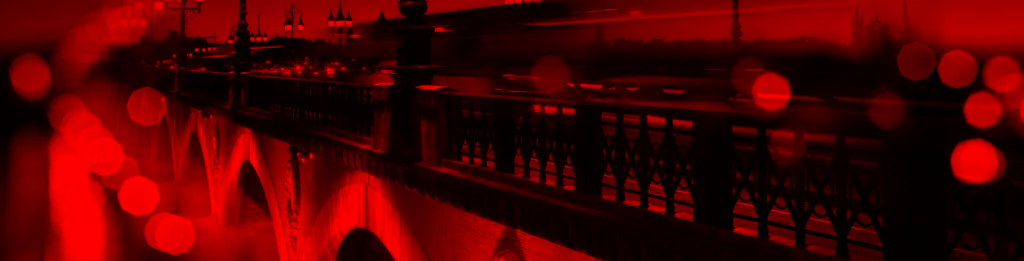

In [14]:
imgpil1


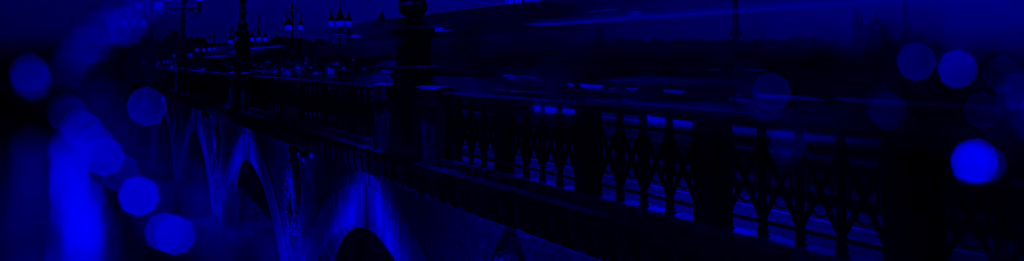

In [13]:
imgpil2


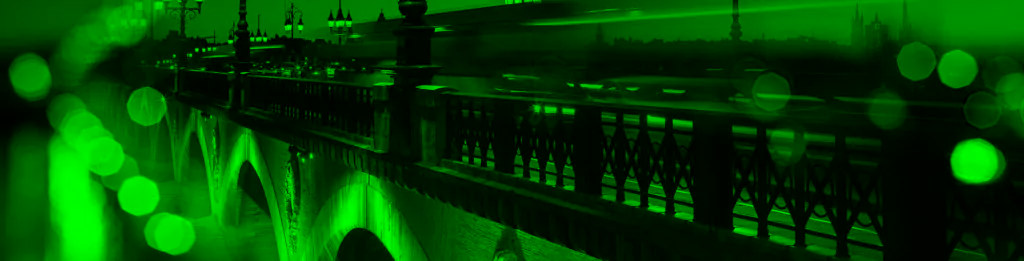

In [17]:
imgpil3

In [ ]:
def filtre(img_orig):
    im = np.copy(img_orig) # On fait une copie de l'original
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (99-r, 99-v,99-b)
    return im


C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_5252\2729590608.py:6: RuntimeWarning: overflow encountered in scalar subtract
  im[i, j] = (99-r, 99-v,99-b)


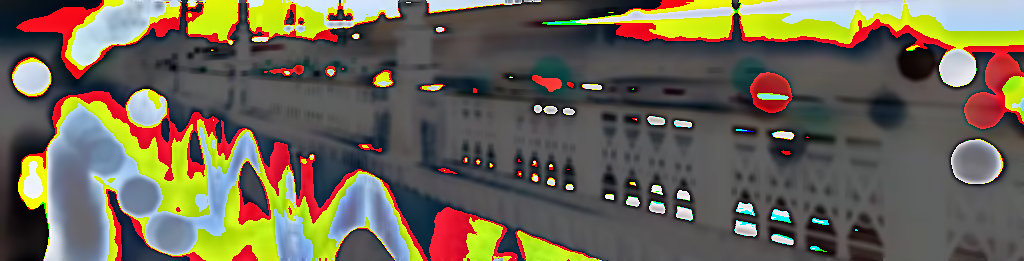

In [41]:
image= Image.fromarray(filtre(img)) # Transformation du tableau en image PIL
image.save("filtre.jpg")
image

In [42]:
from math import pi , exp

def gaussKernel(r,sigma):
    kernel = [[0] * (2*r+1) for _ in range(2*r + 1)]
    if sigma > 0:
        gaussianKernelFactor, e = 0, 0
        for ky in range(-r,r):
            for kx in range(-r,r):
                e = exp(-(kx**2+ky**2)/(2*pi*sigma**2))
                gaussianKernelFactor += e
                kernel[kx+r][ky+r] = e
        
        for ky in range(-r,r):
            for kx in range(-r,r):
                kernel[kx+r][ky+r] = kernel[kx+r][ky+r] / gaussianKernelFactor
                
    return kernel
                
def convolution(img,M):
    px = int( (len(M)-1) / 2 )
    im = img.copy()
    imax = img.shape[1] - px
    for i in range(px,imax):
        for j in range(px,img.shape[0]-px):
            somme = 0.0
            for k in range(-px,px+1):
                for l in range(-px,px+1):
                    somme += img[j+l][i+k] * M[l+px][k+px]
            im[j][i] = somme
    return im

imgpil4 = Image.open("image.jpg")  
img = np.array(imgpil) 
H = gaussKernel(3,10)
imgpil5= Image.fromarray(convolution(img,H))
imgpil.save("resultat_flou.jpg")

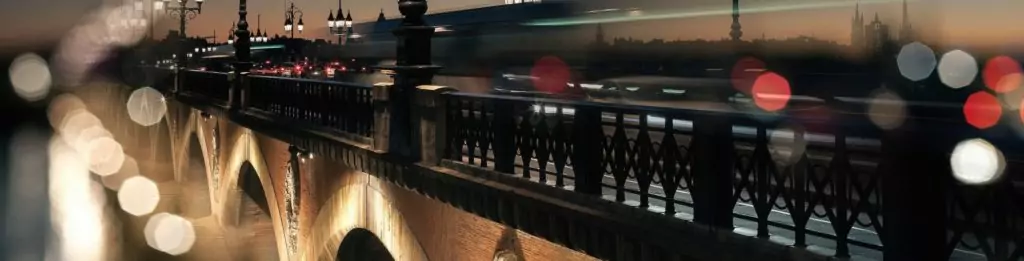

In [43]:
imgpil4

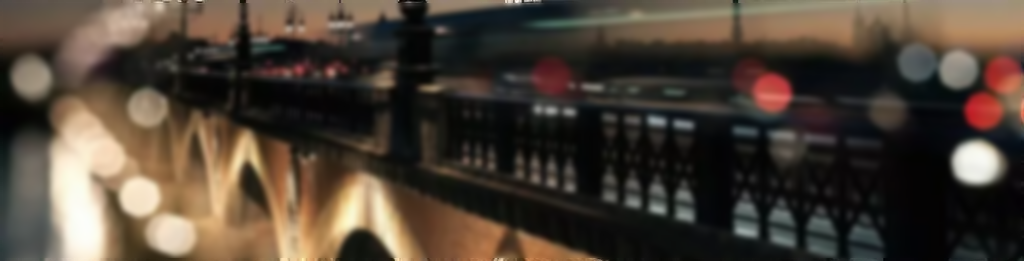

In [44]:
imgpil5

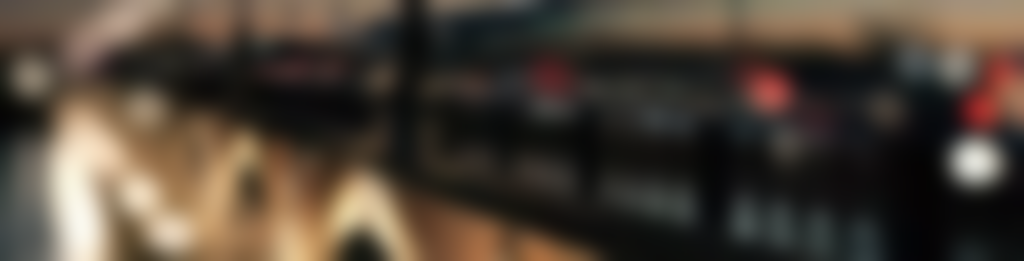

In [46]:
from PIL import Image
from PIL import ImageFilter
from PIL.ImageFilter import (
    GaussianBlur
    )
simg = Image.open('image.jpg')

# defaut: radius=2
dimg = simg.filter(GaussianBlur(radius=10))
dimg.save("image_floue.jpg")
dimg